In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# 1. Load the datasets
# We have features (values) and the target variable (labels) in separate files.
print("Loading datasets...")
values_df = pd.read_csv('train_values.csv')
labels_df = pd.read_csv('train_labels.csv')

Loading datasets...


In [ ]:
# 2. Merge the datasets
# We use an 'inner join' on 'building_id' so every building has its features and its damage grade.
df = pd.merge(values_df, labels_df, on='building_id')


In [ ]:
# 3. Quick Data Inspection
print("\n--- First 5 Rows ---")
display(df.head()) # Use print(df.head()) if not in Jupyter

print("\n--- Dataset Information ---")
# This tells us data types and non-null counts
df.info()


--- First 5 Rows ---


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93245 entries, 0 to 93244
Data columns (total 40 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   building_id                             93245 non-null  int64  
 1   geo_level_1_id                          93245 non-null  int64  
 2   geo_level_2_id                          93245 non-null  int64  
 3   geo_level_3_id                          93245 non-null  int64  
 4   count_floors_pre_eq                     93245 non-null  int64  
 5   age                                     93245 non-null  int64  
 6   area_percentage                         93245 non-null  int64  
 7   height_percentage                       93245 non-null  int64  
 8   land_surface_condition                  93245 non-null  object 
 9   foundation_type                         93245 non-null  object 
 10  roof_type                    

In [ ]:
# STEP 2: DATA CLEANING & PREPARATION

# 1. Check for Missing Values
print("\n--- Missing Values Check ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
# If this prints an empty series, it means our data has NO missing values!
# (Spoiler: This specific DrivenData dataset is pre-cleaned for nulls, but we ALWAYS check).


--- Missing Values Check ---
has_superstructure_stone_flag             1
has_superstructure_cement_mortar_stone    1
has_superstructure_mud_mortar_brick       1
has_superstructure_cement_mortar_brick    1
has_superstructure_timber                 1
has_superstructure_bamboo                 1
has_superstructure_rc_non_engineered      1
has_superstructure_rc_engineered          1
has_superstructure_other                  1
legal_ownership_status                    1
count_families                            1
has_secondary_use                         1
has_secondary_use_agriculture             1
has_secondary_use_hotel                   1
has_secondary_use_rental                  1
has_secondary_use_institution             1
has_secondary_use_school                  1
has_secondary_use_industry                1
has_secondary_use_health_post             1
has_secondary_use_gov_office              1
has_secondary_use_use_police              1
has_secondary_use_other                   1
dt

In [ ]:
# 2. Check for Duplicates
print("\n--- Duplicate Rows Check ---")
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")


--- Duplicate Rows Check ---
Total duplicate rows: 0


In [ ]:
# 3. Fix Data Types (Industry Best Practice)
# String columns (like foundation_type 'r', 'u', etc.) take up a lot of memory.
# Converting them to 'category' data types speeds up processing and saves memory.
print("\n--- Optimizing Data Types ---")
object_columns = df.select_dtypes(include=['object']).columns
for col in object_columns:
    df[col] = df[col].astype('category')

print("Data types optimized successfully!")
print(df.dtypes.value_counts())


--- Optimizing Data Types ---
Data types optimized successfully!
float64     21
int64       11
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


In [ ]:
# Save the cleaned and merged dataset for our next steps!
df.to_csv('cleaned_earthquake_data.csv', index=False)
print("\nCleaned data saved as 'cleaned_earthquake_data.csv'. Ready for EDA!")


Cleaned data saved as 'cleaned_earthquake_data.csv'. Ready for EDA!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [ ]:
# Set plotting style for professional-looking graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# 1. Load the cleaned data from Step 1
print("Loading cleaned dataset...")
df = pd.read_csv('cleaned_earthquake_data.csv')

Loading cleaned dataset...


In [ ]:
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
print("\n--- Starting EDA ---")


--- Starting EDA ---


/tmp/ipykernel_939/784726959.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='damage_grade', palette='Reds')


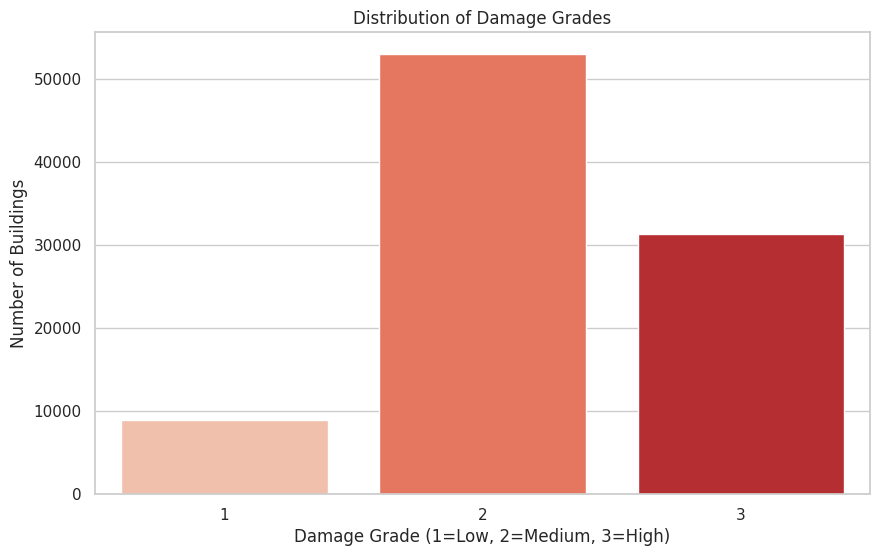

In [ ]:
# Plot 1: Univariate Analysis - Distribution of Target Variable
plt.figure()
sns.countplot(data=df, x='damage_grade', palette='Reds')
plt.title('Distribution of Damage Grades')
plt.xlabel('Damage Grade (1=Low, 2=Medium, 3=High)')
plt.ylabel('Number of Buildings')
plt.show()

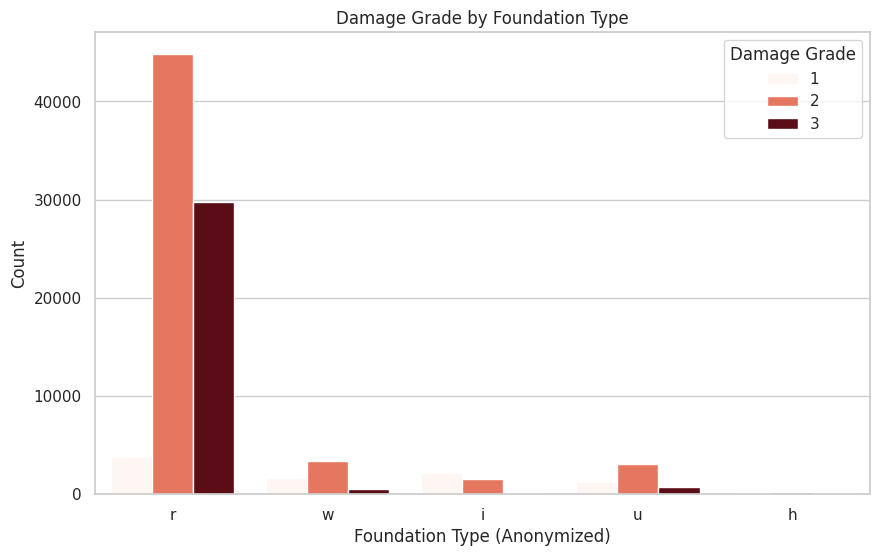

In [ ]:
# Plot 2: Bivariate Analysis - Foundation Type vs Damage
# Does the foundation matter? Let's check!
plt.figure()
sns.countplot(data=df, x='foundation_type', hue='damage_grade', palette='Reds')
plt.title('Damage Grade by Foundation Type')
plt.xlabel('Foundation Type (Anonymized)')
plt.ylabel('Count')
plt.legend(title='Damage Grade')
plt.show()

Generating Correlation Heatmap for numerical features...


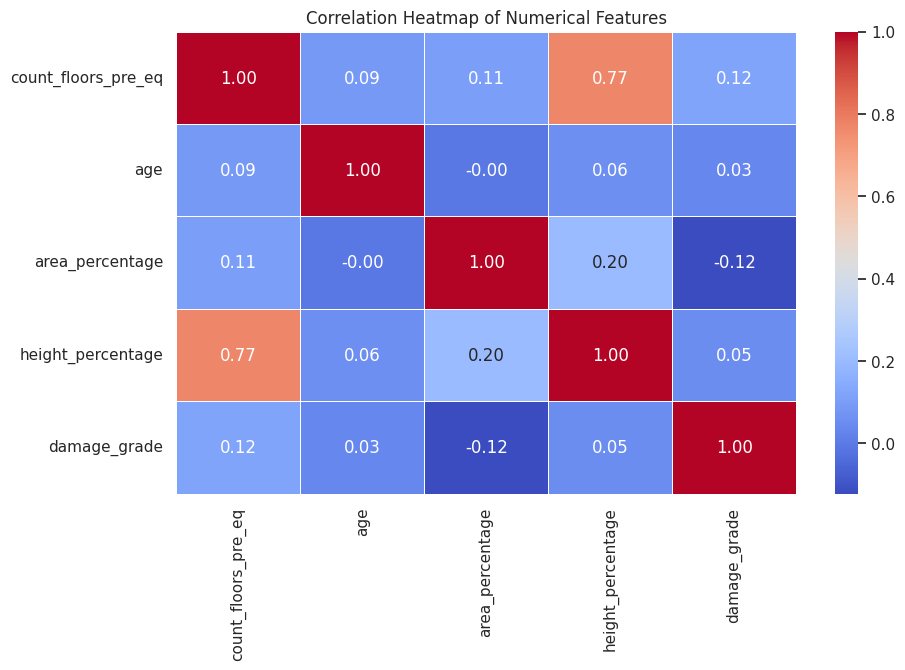

In [ ]:
# Plot 3: Correlation Heatmap
# Let's see how numerical features correlate with each other
print("Generating Correlation Heatmap for numerical features...")
numerical_cols = ['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'damage_grade']
corr_matrix = df[numerical_cols].corr()

plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


In [ ]:
# STEP 4: SQL INTEGRATION
print("\n--- Starting SQL Integration ---")
# Employers love SQL. We will create a local SQLite database, put our dataframe in it, and query it!



--- Starting SQL Integration ---


In [ ]:
# 1. Connect to SQLite (creates a temporary database in memory)
conn = sqlite3.connect(':memory:')

In [ ]:
# 2. Load our dataframe into the SQL database
df.to_sql('buildings', conn, index=False, if_exists='replace')

93245

In [ ]:
# Query A: Damage Distribution (SQL version of Plot 1)
query_distribution = """
SELECT damage_grade, COUNT(*) as total_buildings
FROM buildings
GROUP BY damage_grade
ORDER BY damage_grade;
"""
print("\n[SQL] Damage Distribution:")
display(pd.read_sql_query(query_distribution, conn))


[SQL] Damage Distribution:


,damage_grade,total_buildings
0,1,8948
1,2,52984
2,3,31313


In [ ]:
# Query B: Average Age of Buildings by Damage Grade
# Note: We filter age < 995 because the dataset uses 995 as a placeholder for "very old / unknown"
query_age = """
SELECT damage_grade, ROUND(AVG(age), 2) as avg_age
FROM buildings
WHERE age < 995
GROUP BY damage_grade
ORDER BY damage_grade;
"""
print("\n[SQL] Average Age by Damage Grade (excluding unknowns):")
display(pd.read_sql_query(query_age, conn))


[SQL] Average Age by Damage Grade (excluding unknowns):


,damage_grade,avg_age
0,1,10.12
1,2,21.90
2,3,23.50


In [ ]:
# Query C: Which foundation type survived the best? (Damage Grade 1)
query_foundation = """
SELECT foundation_type,
       COUNT(*) as total_buildings,
       SUM(CASE WHEN damage_grade = 1 THEN 1 ELSE 0 END) as low_damage_count,
       ROUND((SUM(CASE WHEN damage_grade = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*)), 2) as survival_rate_pct
FROM buildings
GROUP BY foundation_type
ORDER BY survival_rate_pct DESC;
"""
print("\n[SQL] Survival Rate by Foundation Type:")
display(pd.read_sql_query(query_foundation, conn))



[SQL] Survival Rate by Foundation Type:


,foundation_type,total_buildings,low_damage_count,survival_rate_pct
0,i,3793,2121,55.92
1,w,5486,1605,29.26
2,h,490,130,26.53
3,u,5046,1280,25.37
4,r,78430,3812,4.86


In [ ]:
# Close the connection
conn.close()
print("\nEDA and SQL Analysis Complete!")


EDA and SQL Analysis Complete!


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("Loading cleaned dataset for preparation...")
df = pd.read_csv('cleaned_earthquake_data.csv')

Loading cleaned dataset for preparation...


In [ ]:
# STEP 5: FEATURE ENGINEERING
# ==========================================
print("\n--- Starting Feature Engineering ---")


--- Starting Feature Engineering ---


In [ ]:
# 1. Building Volume / Size Index
# We have 'area_percentage' and 'height_percentage'. Multiplying them gives a proxy for the total volume/mass of the building.
# Heavier/larger buildings might react differently to earthquakes!
df['building_volume_index'] = df['area_percentage'] * df['height_percentage']
print("Created new feature: 'building_volume_index'")

Created new feature: 'building_volume_index'


In [ ]:
# 2. Age Categorization
# Remember how '995' meant unknown/historic? Let's create a specific flag for historic buildings.
df['is_historic_or_unknown'] = (df['age'] >= 200).astype(int)
print("Created new feature: 'is_historic_or_unknown'")

Created new feature: 'is_historic_or_unknown'


In [ ]:
# Let's see our new columns!
print("\nNew Features Sample:")
display(df[['area_percentage', 'height_percentage', 'building_volume_index', 'age', 'is_historic_or_unknown']].head())


New Features Sample:


,area_percentage,height_percentage,building_volume_index,age,is_historic_or_unknown
0,6,5,30,30,0
1,8,7,56,10,0
2,5,5,25,10,0
3,6,5,30,10,0
4,8,9,72,30,0


In [ ]:
# STEP 6: DATA PREPARATION
# ==========================================
print("\n--- Starting Data Preparation ---")


--- Starting Data Preparation ---


In [ ]:
# 1. Drop unnecessary columns
# 'building_id' is just an identifier, it has no predictive power. If we leave it in, the model might try to learn from it!
X = df.drop(['damage_grade', 'building_id'], axis=1)
y = df['damage_grade'] # This is what we want to predict

In [ ]:
# 2. Encode Categorical Variables
# Machine learning models only understand NUMBERS, not text like 'r' or 'q'.
# We use One-Hot Encoding (pd.get_dummies) to turn text categories into binary (0 or 1) columns.
print("\nEncoding categorical variables...")
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Original feature count: {X.shape[1]}")
print(f"Encoded feature count: {X_encoded.shape[1]} (Notice how it expanded!)")



Encoding categorical variables...
Original feature count: 40
Encoded feature count: 62 (Notice how it expanded!)


In [ ]:
# 3. Train-Test Split
# We must hide some data from our model so we can test it fairly later (like a final exam).
# We'll use 80% of data for training, and 20% for testing.
print("\nSplitting data into Train and Test sets...")
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

print("\nData Preparation Complete! We are ready for Machine Learning.")


Splitting data into Train and Test sets...
Training data shape: (74596, 62)
Testing data shape: (18649, 62)

Data Preparation Complete! We are ready for Machine Learning.


In [ ]:
# If you don't have xgboost installed, uncomment and run the line below in a cell first:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, cohen_kappa_score

In [ ]:
# STEP 7: MODELING (Training & Evaluation)
# ==========================================
print("--- Starting Model Training ---")
print("Note: Random Forest and XGBoost might take a minute or two to train. Grab some water!\n")

--- Starting Model Training ---
Note: Random Forest and XGBoost might take a minute or two to train. Grab some water!



In [ ]:
# 1. Initialize Models
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10) # Limited depth so it doesn't overfit
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15, n_jobs=-1)

In [ ]:
# XGBoost requires target labels to start at 0 (so 1,2,3 becomes 0,1,2)
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1
xgb_model = XGBClassifier(random_state=42, n_estimators=100, max_depth=10, learning_rate=0.1, n_jobs=-1)

In [ ]:
# 2. Train Models
print("Training Decision Tree...")
dt_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train_xgb)

Training Decision Tree...
Training Random Forest...
Training XGBoost...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# 3. Make Predictions
dt_preds = dt_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test) + 1 # Add 1 back to match original 1,2,3 labels

In [ ]:
# 4. Evaluate Models
def evaluate_model(name, y_true, y_pred):
    # We use 'weighted' for precision/recall because our classes (1,2,3) are imbalanced
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    print(f"[{name}] Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | Kappa: {kappa:.4f}")

print("\n--- Model Evaluation Results ---")
evaluate_model("Decision Tree", y_test, dt_preds)
evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost      ", y_test, xgb_preds)


--- Model Evaluation Results ---
[Decision Tree] Accuracy: 0.6754 | Precision: 0.6704 | Recall: 0.6754 | Kappa: 0.3790
[Random Forest] Accuracy: 0.6676 | Precision: 0.6855 | Recall: 0.6676 | Kappa: 0.3232
[XGBoost      ] Accuracy: 0.7159 | Precision: 0.7155 | Recall: 0.7159 | Kappa: 0.4559


In [ ]:
# STEP 8: INSIGHTS (Feature Importance)
# ==========================================
print("\n--- Extracting Key Insights ---")


--- Extracting Key Insights ---


In [ ]:
# We will use Random Forest to tell us which features were the most important for predicting damage
importances = rf_model.feature_importances_
feature_names = X_train.columns

In [ ]:
# Create a DataFrame to easily sort and view the importances
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10) # Top 10

/tmp/ipykernel_939/299614903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


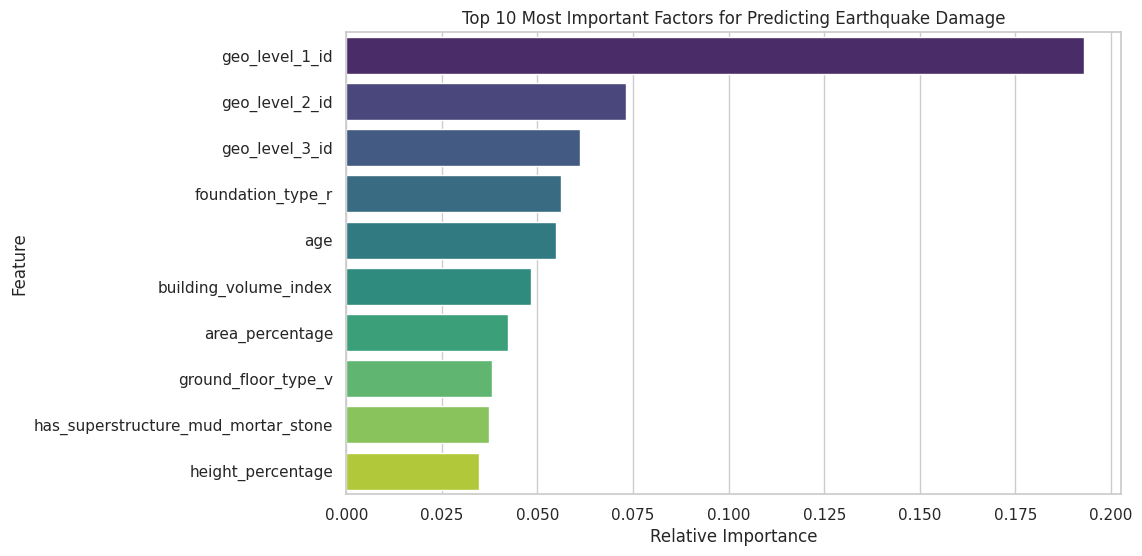

In [ ]:
# Plotting the Top 10 Features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Factors for Predicting Earthquake Damage')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

1. Fix the Weak Foundations (Help people upgrade)

What the data says: Buildings with the 'r' type foundation break very easily in an earthquake. Buildings with the 'i' type survive much better.

What we should do: The government should find all houses with 'r' foundations and give those owners financial help (like tax breaks or grants) to upgrade to the safer 'i' foundation.

2. Make Strict Rules for Old and Big Buildings

What the data says: Buildings that are very old, or very tall and heavy, suffer the most damage.

What we should do: Create a new rule: Any building over 50 years old must be inspected to ensure it is still safe. Also, stop builders from making overly tall or heavy buildings in known earthquake zones.

3. Put Emergency Supplies in the Right Locations

What the data says: The exact location (geo_level) was the #1 biggest clue if a building would be destroyed.

What we should do: Don't just keep medical supplies and rescue tents in the capital city. Store them permanently in the specific towns and regions our model identified as "high risk" so help is already there when an earthquake hits.bold text

In [ ]:
from google.colab import files
files.download('cleaned_earthquake_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>